# Dynamic Programming: Value Iteration & Policy Iteration

**A hands-on tutorial with theory and a NumPy implementation**

---

Before there were neural networks in reinforcement learning, before Q-learning, and before deep RL, there was
**dynamic programming (DP)**. Richard Bellman introduced the term and the *Bellman equation* in the 1950s
([Bellman, 1957](https://press.princeton.edu/books/paperback/9780691146683/dynamic-programming)), and Ronald Howard
formalized **policy iteration** in 1960. Together they form the mathematical bedrock of the entire field: every modern
RL algorithm — Q-learning, DQN, actor-critic, AlphaZero — is a way of *approximately* solving the Bellman equations
when you don't have (or can't afford to use) the exact model of the environment.

DP methods assume a **known model** of the environment (transition probabilities and rewards) and compute the optimal
policy by *planning* rather than by trial-and-error interaction. That makes them the perfect place to start: the ideas
are crisp, the algorithms provably converge, and we can look at every intermediate quantity.

## What you will learn

1. The **Bellman expectation** and **Bellman optimality** equations, and why they have unique solutions.
2. **Policy evaluation**: computing $V^\pi$ for a fixed policy by iterating the Bellman operator.
3. **Policy iteration** (Howard, 1960): alternate evaluation and greedy improvement.
4. **Value iteration** (Bellman, 1957): fold improvement into every sweep.
5. A **from-scratch NumPy implementation** on the stochastic `FrozenLake-v1` 8×8 grid world.
6. How DP relates to Q-learning, DQN and modern model-based methods like MuZero.

## Notebook outline

1. MDPs and the Bellman equations
2. The environment: FrozenLake and its transition model
3. Policy evaluation
4. Policy iteration
5. Value iteration
6. Comparing the two algorithms
7. Visualizing the value function and the optimal policy
8. Evaluating the learned policy
9. **Visual demonstration** of the trained agent
10. Strengths, weaknesses & connections
11. References

## 0. Setup

This notebook is pure NumPy — no deep learning framework is needed. We use `gymnasium` (the maintained fork of
OpenAI Gym) for environments, `pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs.
If you don't have these installed, uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import time
import warnings
from collections import defaultdict

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
rng = np.random.default_rng(SEED)
print(f"gymnasium version: {gym.__version__}")

gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. MDPs and the Bellman Equations

### 1.1 The Markov Decision Process

A finite **Markov Decision Process (MDP)** is the tuple $(\mathcal{S}, \mathcal{A}, P, r, \gamma)$:

- $\mathcal{S}$: a finite set of **states**, $\mathcal{A}$: a finite set of **actions**
- $P(s' \mid s, a)$: **transition probabilities**
- $r(s, a, s')$: **reward** for the transition
- $\gamma \in [0, 1)$: **discount factor**

A **policy** $\pi(a \mid s)$ tells the agent what to do. The **state-value function** of $\pi$ is the expected
discounted return starting from $s$:

$$
V^\pi(s) \;=\; \mathbb{E}_\pi\!\left[\sum_{t=0}^{\infty} \gamma^t\, r_t \;\middle|\; s_0 = s\right].
$$

### 1.2 The Bellman expectation equation

The defining property of DP is that the value of a state decomposes **recursively** into the immediate reward plus the
discounted value of the next state:

$$
\boxed{\,V^\pi(s) \;=\; \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a)\,\big[\, r(s,a,s') + \gamma\, V^\pi(s') \,\big]\,}
$$

This is a *linear system* of $|\mathcal{S}|$ equations in $|\mathcal{S}|$ unknowns. One could solve it directly with
linear algebra, but the iterative approach generalizes far better.

### 1.3 The Bellman optimality equation

The optimal value function $V^*(s) = \max_\pi V^\pi(s)$ satisfies

$$
\boxed{\,V^*(s) \;=\; \max_a \sum_{s'} P(s' \mid s, a)\,\big[\, r(s,a,s') + \gamma\, V^*(s') \,\big]\,}
$$

and the optimal policy is the greedy policy with respect to $V^*$: $\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a)[r + \gamma V^*(s')]$.
Equivalently, in terms of the **action-value** function $Q^*(s,a)$:

$$
Q^*(s, a) \;=\; \sum_{s'} P(s' \mid s, a)\,\big[\, r(s,a,s') + \gamma \max_{a'} Q^*(s', a') \,\big], \qquad \pi^*(s) = \arg\max_a Q^*(s,a).
$$

### 1.4 Why iteration works: the Bellman operator is a contraction

Define the **Bellman optimality operator** $(\mathcal{T} V)(s) = \max_a \sum_{s'} P(s'|s,a)[r + \gamma V(s')]$.
For any two value functions $U, V$:

$$
\|\mathcal{T}U - \mathcal{T}V\|_\infty \;\le\; \gamma\, \|U - V\|_\infty .
$$

Because $\gamma < 1$, $\mathcal{T}$ is a **$\gamma$-contraction** in the max-norm. By the Banach fixed-point theorem it has
a unique fixed point ($V^*$), and repeatedly applying $\mathcal{T}$ from *any* starting point converges to it geometrically
fast: $\|\mathcal{T}^k V - V^*\|_\infty \le \gamma^k \|V - V^*\|_\infty$. The same argument applies to the Bellman
expectation operator $\mathcal{T}^\pi$ and $V^\pi$. This single fact is why value iteration, policy evaluation, and —
in a sample-based form — Q-learning all converge.

## 2. The Environment: FrozenLake

`FrozenLake-v1` is a classic grid world. The agent starts at **S**, must reach the goal **G**, and falls through holes
**H**. The ice is *slippery*: each action succeeds with probability 1/3 and slips perpendicular to the intended direction
with probability 1/3 each. The only reward is $+1$ for reaching the goal; every other transition gives $0$.

We use the harder **8×8** map. Crucially for DP, `gymnasium` exposes the full transition model as
`env.unwrapped.P[s][a] = [(prob, next_state, reward, terminated), ...]`, so we can plan instead of learning from samples.

In [4]:
ENV_KWARGS = dict(map_name="8x8", is_slippery=True, max_episode_steps=200)
env = gym.make("FrozenLake-v1", **ENV_KWARGS)

nS = env.observation_space.n
nA = env.action_space.n
P = env.unwrapped.P                       # the model: P[s][a] -> list of (prob, s', r, done)
desc = env.unwrapped.desc.astype(str)     # the map as characters
nrow, ncol = desc.shape
ACTION_NAMES = ["Left", "Down", "Right", "Up"]

print(f"{nS} states, {nA} actions, grid {nrow}x{ncol}")
print("\n".join("".join(row) for row in desc))
print("\nTransitions from the start state when taking action 'Right':")
for prob, s_next, r, done in P[0][2]:
    print(f"  prob={prob:.3f} -> state {s_next:2d} (row {s_next // ncol}, col {s_next % ncol}), reward={r}, done={done}")

64 states, 4 actions, grid 8x8
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Transitions from the start state when taking action 'Right':
  prob=0.333 -> state  8 (row 1, col 0), reward=0, done=False
  prob=0.333 -> state  1 (row 0, col 1), reward=0, done=False
  prob=0.333 -> state  0 (row 0, col 0), reward=0, done=False


Slipperiness is visible above: "Right" moves right only one third of the time, and otherwise slips up (bumping into the wall,
staying put) or down. This stochasticity is exactly why we need expectations in the Bellman equations rather than a simple
shortest-path search.

## 3. Policy Evaluation

Given a policy $\pi$, **iterative policy evaluation** repeatedly applies the Bellman expectation operator:

$$
V_{k+1}(s) \;\leftarrow\; \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a)\,\big[\, r + \gamma\, V_k(s') \,\big].
$$

We stop when the largest change in any state, $\Delta = \max_s |V_{k+1}(s) - V_k(s)|$, drops below a threshold $\theta$.
We update states **in place** (Gauss–Seidel style) — using fresh values as soon as they are available — which typically
converges faster than a synchronous sweep.

A tiny helper, `q_from_v`, computes the one-step lookahead $Q(s, \cdot)$ from a value function; it is the workhorse of
both improvement and value iteration.

In [5]:
def q_from_v(P, s, V, gamma):
    """One-step lookahead: Q(s, a) = sum_{s'} P(s'|s,a) [r + gamma V(s')] for every action a."""
    q = np.zeros(len(P[s]))
    for a, transitions in P[s].items():
        for prob, s_next, r, done in transitions:
            q[a] += prob * (r + gamma * V[s_next] * (not done))
    return q


def policy_evaluation(P, policy, gamma=0.99, theta=1e-8, max_sweeps=10_000):
    """Iterative (in-place) policy evaluation. `policy` is an (nS, nA) array of action probabilities."""
    nS = len(P)
    V = np.zeros(nS)
    for sweep in range(1, max_sweeps + 1):
        delta = 0.0
        for s in range(nS):
            v_new = policy[s] @ q_from_v(P, s, V, gamma)
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    return V, sweep


GAMMA = 0.99
uniform_policy = np.full((nS, nA), 1.0 / nA)
V_uniform, sweeps = policy_evaluation(P, uniform_policy, GAMMA)
print(f"Uniform random policy evaluated in {sweeps} sweeps. V(start) = {V_uniform[0]:.4f}")

Uniform random policy evaluated in 139 sweeps. V(start) = 0.0011


The value of the start state under a uniform random policy is the probability (discounted) of stumbling into the goal
before falling into a hole — tiny, as expected for an 8×8 slippery lake.

## 4. Policy Iteration

**Policy improvement theorem** (Howard, 1960; see Sutton & Barto §4.2). Let $\pi'$ be the greedy policy with respect
to $Q^\pi$: $\pi'(s) = \arg\max_a Q^\pi(s,a)$. Then $V^{\pi'}(s) \ge V^\pi(s)$ for all $s$, with strict improvement in
some state unless $\pi$ is already optimal.

**Policy iteration** simply alternates the two steps until the policy stops changing:

$$
\pi_0 \xrightarrow{\text{evaluate}} V^{\pi_0} \xrightarrow{\text{improve}} \pi_1 \xrightarrow{\text{evaluate}} V^{\pi_1} \xrightarrow{\text{improve}} \pi_2 \;\cdots\; \rightarrow \pi^*
$$

Because there are finitely many deterministic policies and each step improves strictly (or terminates), policy
iteration converges to $\pi^*$ in a finite number of iterations — usually remarkably few.

In [6]:
def policy_improvement(P, V, gamma):
    """Greedy (deterministic) policy w.r.t. V, returned as an (nS, nA) one-hot array."""
    nS, nA = len(P), len(P[0])
    policy = np.zeros((nS, nA))
    for s in range(nS):
        policy[s, np.argmax(q_from_v(P, s, V, gamma))] = 1.0
    return policy


def policy_iteration(P, gamma=0.99, theta=1e-8, verbose=True):
    nS, nA = len(P), len(P[0])
    policy = np.full((nS, nA), 1.0 / nA)
    history = []
    for it in range(1, 1000):
        V, sweeps = policy_evaluation(P, policy, gamma, theta)
        new_policy = policy_improvement(P, V, gamma)
        n_changed = int((new_policy.argmax(1) != policy.argmax(1)).sum())
        history.append(dict(iteration=it, eval_sweeps=sweeps, changed=n_changed, V=V.copy()))
        if verbose:
            print(f"iter {it:2d}: {sweeps:4d} evaluation sweeps, {n_changed:2d} states changed action, V(start)={V[0]:.4f}")
        if n_changed == 0:
            break
        policy = new_policy
    return V, policy, history


t0 = time.time()
V_pi, pi_pi, hist_pi = policy_iteration(P, GAMMA)
print(f"\nPolicy iteration converged in {len(hist_pi)} iterations ({time.time() - t0:.2f}s)")

iter  1:  139 evaluation sweeps, 43 states changed action, V(start)=0.0011


iter  2:  442 evaluation sweeps,  7 states changed action, V(start)=0.3776


iter  3:  349 evaluation sweeps,  1 states changed action, V(start)=0.4146


iter  4:  349 evaluation sweeps,  0 states changed action, V(start)=0.4146

Policy iteration converged in 4 iterations (0.46s)


Only a handful of improvement steps are needed — after the second one, the policy changes in just a few states.
But look at the cost: every evaluation runs *hundreds* of sweeps to full convergence, and almost all of that precision is
wasted, because the next improvement step only cares about which action is *best*, not about the exact values. This
observation motivates value iteration.

## 5. Value Iteration

Policy iteration does a *full* evaluation before each improvement, which is wasteful. **Value iteration** truncates
evaluation to a *single sweep* and folds the greedy improvement directly into the update by taking a $\max$:

$$
\boxed{\,V_{k+1}(s) \;\leftarrow\; \max_a \sum_{s'} P(s' \mid s, a)\,\big[\, r + \gamma\, V_k(s') \,\big]\,}
$$

This is nothing but repeated application of the Bellman optimality operator $\mathcal{T}$, so by the contraction
argument $V_k \to V^*$. Once we stop, we extract the greedy policy. Value iteration is the direct ancestor of
**Q-learning**: replace the expectation over $P$ with a single sampled transition and you get the Q-learning update.

In [7]:
def value_iteration(P, gamma=0.99, theta=1e-8, max_sweeps=10_000):
    nS = len(P)
    V = np.zeros(nS)
    history = []                       # snapshot of V after each sweep (for the animation below)
    for sweep in range(1, max_sweeps + 1):
        delta = 0.0
        for s in range(nS):
            v_new = np.max(q_from_v(P, s, V, gamma))
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        history.append(dict(sweep=sweep, delta=delta, V=V.copy()))
        if delta < theta:
            break
    policy = policy_improvement(P, V, gamma)
    return V, policy, history


t0 = time.time()
V_vi, pi_vi, hist_vi = value_iteration(P, GAMMA)
print(f"Value iteration converged in {len(hist_vi)} sweeps ({time.time() - t0:.2f}s). V(start) = {V_vi[0]:.4f}")

Value iteration converged in 347 sweeps (0.16s). V(start) = 0.4146


## 6. Comparing the Two Algorithms

Both algorithms must reach the same $V^*$ and (up to ties) the same $\pi^*$. Let's check, and look at how the Bellman
residual $\Delta$ decays for value iteration — it should be geometric with rate $\approx \gamma$ in the worst case, but
in practice much faster on sparse grid worlds.

max |V_PI - V_VI| = 5.99e-10
states where the greedy actions differ: 0
Policy iteration: 4 improvement steps, 1279 total evaluation sweeps
Value iteration : 347 sweeps


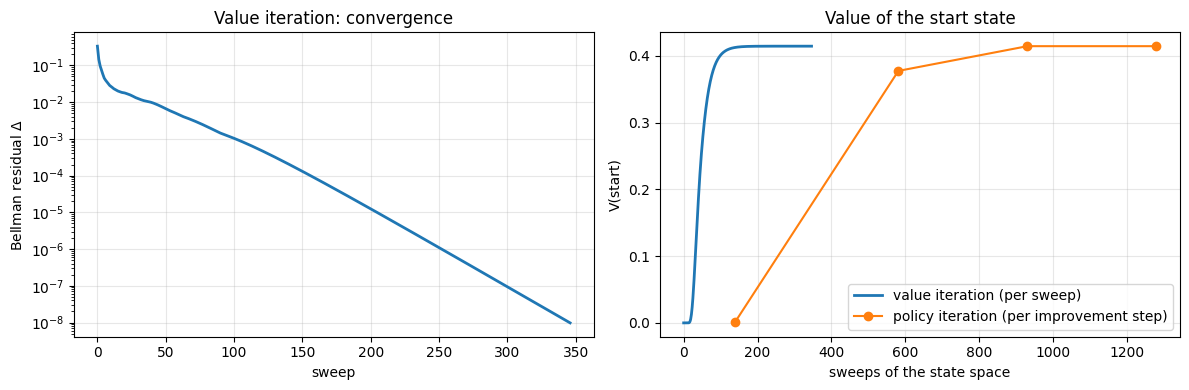

In [8]:
print(f"max |V_PI - V_VI| = {np.abs(V_pi - V_vi).max():.2e}")
print(f"states where the greedy actions differ: {(pi_pi.argmax(1) != pi_vi.argmax(1)).sum()}")
total_pi_sweeps = sum(h["eval_sweeps"] for h in hist_pi)
print(f"Policy iteration: {len(hist_pi)} improvement steps, {total_pi_sweeps} total evaluation sweeps")
print(f"Value iteration : {len(hist_vi)} sweeps")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy([h["delta"] for h in hist_vi], lw=2)
axes[0].set_xlabel("sweep")
axes[0].set_ylabel(r"Bellman residual $\Delta$")
axes[0].set_title("Value iteration: convergence")
axes[0].grid(alpha=0.3)

axes[1].plot([h["V"][0] for h in hist_vi], lw=2, label="value iteration (per sweep)")
axes[1].plot(np.cumsum([h["eval_sweeps"] for h in hist_pi]), [h["V"][0] for h in hist_pi], "o-",
             label="policy iteration (per improvement step)")
axes[1].set_xlabel("sweeps of the state space")
axes[1].set_ylabel("V(start)")
axes[1].set_title("Value of the start state")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the plots:** the residual of value iteration drops geometrically (a straight line on the log scale) — the
contraction property made visible. Policy iteration needs far fewer *improvement* steps but each one requires a full
evaluation, so the total number of sweeps ends up comparable. In practice, **modified policy iteration** (a few
evaluation sweeps per improvement) is often the sweet spot.

## 7. Visualizing $V^*$ and $\pi^*$

A grid world lets us look at the whole solution at once: the value of every state as a heatmap, and the greedy action as
an arrow. Look at how the arrows near holes often point *into the wall* — on slippery ice the safest way past a hole is
to press against a wall and let the slips carry you.

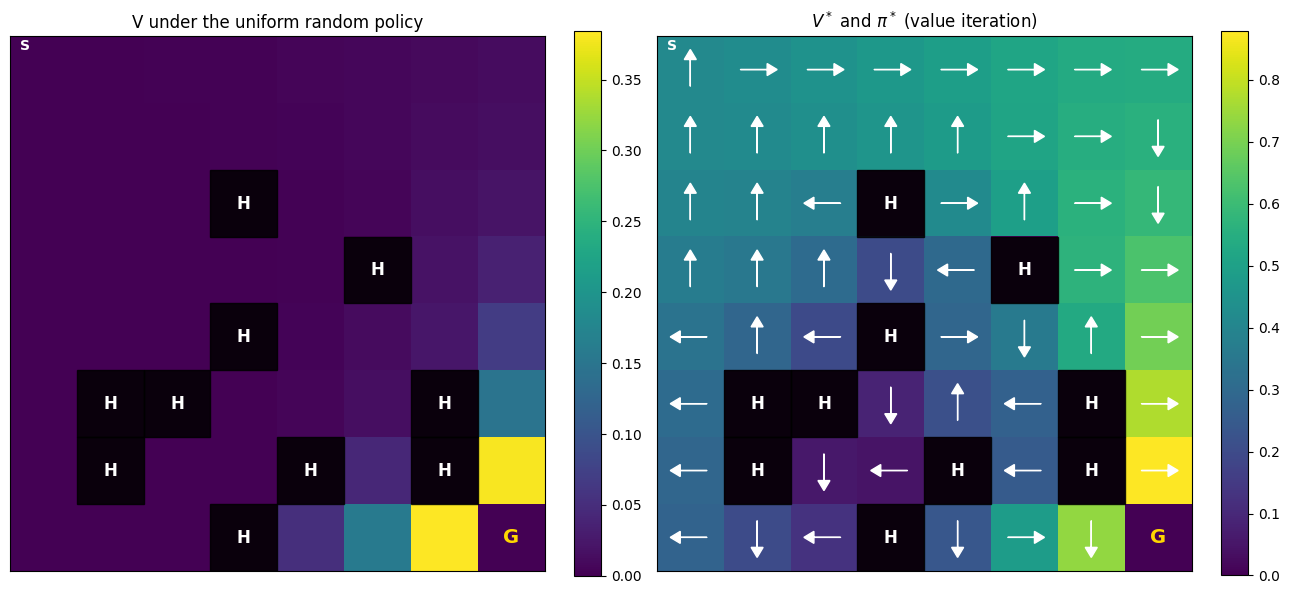

In [9]:
ARROWS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}   # Left, Down, Right, Up as (dx, dy) in plot coords


def plot_grid_values(V, policy=None, title="", ax=None, show_arrows=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    grid = V.reshape(nrow, ncol)
    im = ax.imshow(grid, cmap="viridis", vmin=0, vmax=max(V.max(), 1e-9))
    for r in range(nrow):
        for c in range(ncol):
            s = r * ncol + c
            ch = desc[r, c]
            if ch == "H":
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="black", alpha=0.85))
                ax.text(c, r, "H", ha="center", va="center", color="white", fontsize=12, weight="bold")
            elif ch == "G":
                ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=14, weight="bold")
            else:
                if ch == "S":
                    ax.text(c - 0.35, r - 0.3, "S", color="white", fontsize=10, weight="bold")
                if policy is not None and show_arrows:
                    dx, dy = ARROWS[int(policy[s].argmax())]
                    ax.arrow(c - 0.25 * dx, r - 0.25 * dy, 0.4 * dx, 0.4 * dy,
                             head_width=0.18, head_length=0.15, fc="white", ec="white", lw=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
im = plot_grid_values(V_uniform, None, "V under the uniform random policy", axes[0])
plt.colorbar(im, ax=axes[0], fraction=0.046)
im = plot_grid_values(V_vi, pi_vi, r"$V^*$ and $\pi^*$ (value iteration)", axes[1])
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

### 7.1 Watching value iteration converge

Each sweep propagates value one step further from the goal. Animating the snapshots makes the "backward induction"
nature of DP obvious: information flows from the goal outward.

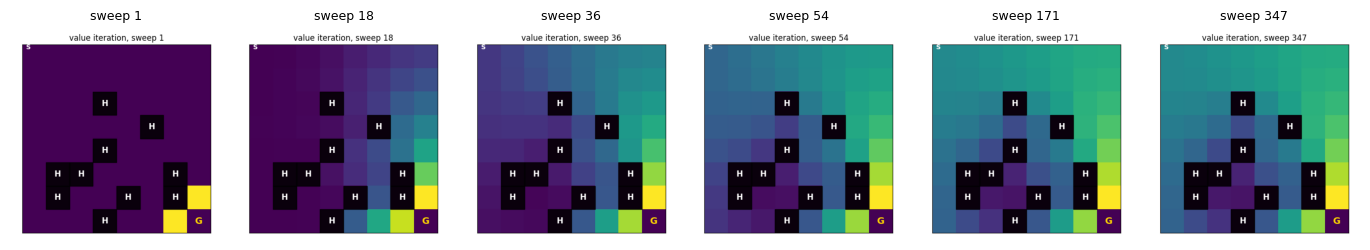

Saved media/dp_value_iteration_sweeps.gif  (90 frames, 0.65 MB)


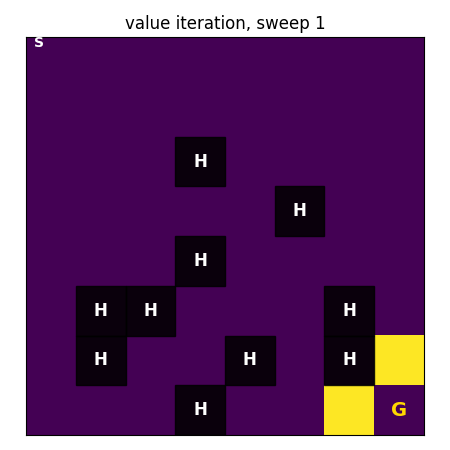

In [10]:
def fig_to_rgb(fig):
    """Rasterize a matplotlib figure into an RGB numpy array."""
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()


frames_vi = []
snapshots = list(range(0, min(len(hist_vi), 60))) + list(range(60, len(hist_vi), 10)) + [len(hist_vi) - 1]
for k in snapshots:
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    plot_grid_values(hist_vi[k]["V"], None, f"value iteration, sweep {hist_vi[k]['sweep']}", ax)
    fig.tight_layout()
    frames_vi.append(fig_to_rgb(fig))
    plt.close(fig)

show_filmstrip(frames_vi, n=6, captions=[f"sweep {hist_vi[k]['sweep']}" for k in snapshots])
save_gif(frames_vi, "dp_value_iteration_sweeps", fps=8, downscale=1)

## 8. Evaluating the Learned Policy

With $\gamma = 0.99$, $V^*(s_0)$ mixes *whether* the agent reaches the goal with *how long* it takes, so it is not directly
a success probability. But DP can answer the undiscounted question too: evaluating the optimal policy with $\gamma = 1$
gives exactly the probability of eventually reaching the goal. Let's compute that, then check it against Monte Carlo
rollouts in the real environment (also a sanity check that `env.unwrapped.P` matches the simulator), and compare with a
random policy.

In [11]:
V_success, _ = policy_evaluation(P, pi_vi, gamma=1.0, theta=1e-10)   # undiscounted -> P(reach goal | s)


def run_episodes(env, act_fn, n_episodes=2000, seed=0):
    successes, lengths = 0, []
    for i in range(n_episodes):
        s, _ = env.reset(seed=seed + i)
        for t in range(1, 10_000):
            s, r, terminated, truncated, _ = env.step(act_fn(s))
            if terminated or truncated:
                successes += int(r > 0)
                lengths.append(t)
                break
    return successes / n_episodes, np.mean(lengths)


rate_opt, len_opt = run_episodes(env, lambda s: int(pi_vi[s].argmax()))
rate_rand, len_rand = run_episodes(env, lambda s: env.action_space.sample())

print(f"DP prediction for the optimal policy: P(reach goal) = {V_success[0]:.3f}  (discounted V*(start) = {V_vi[0]:.3f})")
print(f"Optimal policy : empirical success rate {rate_opt:.3f}, mean episode length {len_opt:.1f}")
print(f"Random policy  : empirical success rate {rate_rand:.3f}, mean episode length {len_rand:.1f}")

DP prediction for the optimal policy: P(reach goal) = 0.894  (discounted V*(start) = 0.415)
Optimal policy : empirical success rate 0.869, mean episode length 84.3
Random policy  : empirical success rate 0.002, mean episode length 32.7


The empirical success rate matches the undiscounted DP prediction (the small gap is the 200-step time limit, which the
model does not know about). A random walk on the 8×8 slippery lake essentially never makes it.

## 9. Visual Demonstration

Let's watch the optimal policy in action. Because the ice is slippery, the trajectory looks like a drunkard's walk —
but a *biased* one that hugs walls, avoids holes, and eventually makes it to the goal. We record one successful
episode and one that ends in a hole to be honest about the stochasticity.

Successful episode: seed=0, 61 steps


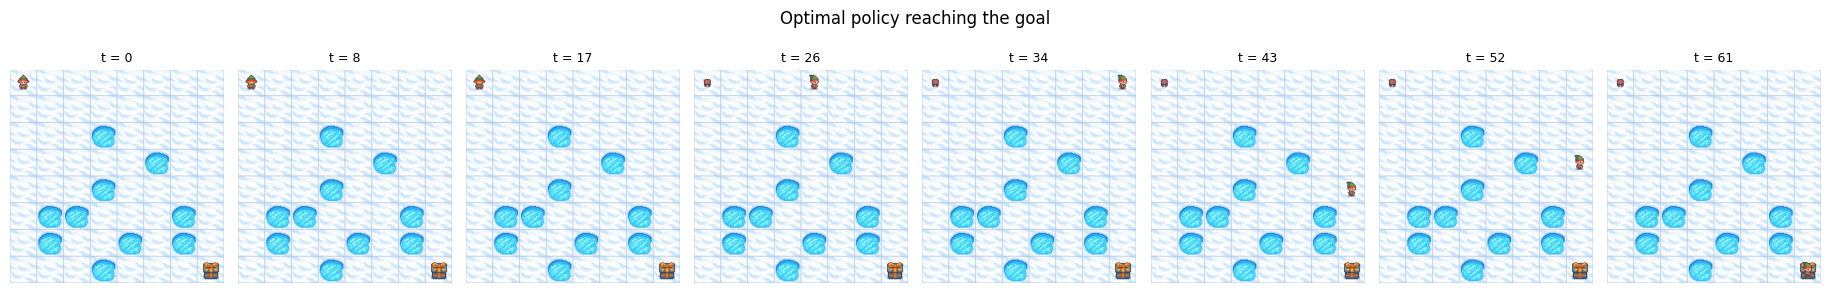

Unlucky episode: seed=6, fell in a hole after 176 steps


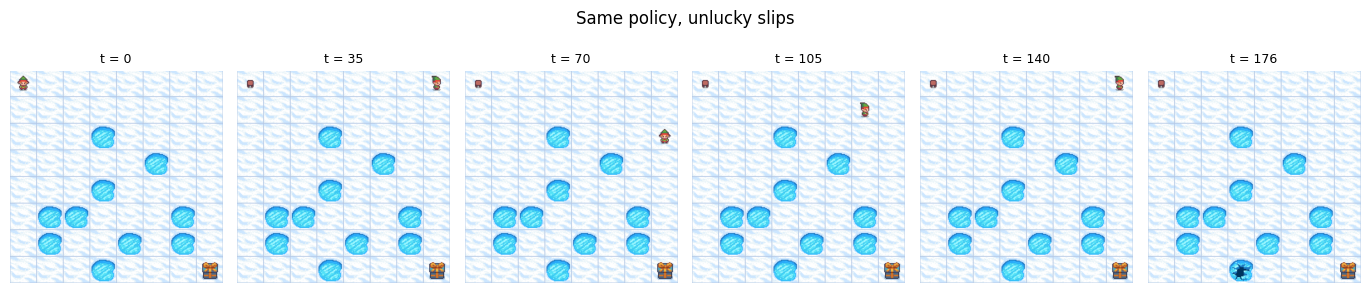

In [12]:
render_env = gym.make("FrozenLake-v1", render_mode="rgb_array", **ENV_KWARGS)
act_greedy = lambda s: int(pi_vi[s].argmax())

success_frames, failure_frames = None, None
for seed in range(100):
    frames, ep_ret, ep_len = record_episode(render_env, act_greedy, seed=seed, max_steps=200)
    if ep_ret > 0 and success_frames is None:
        success_frames, success_info = frames, (seed, ep_len)
    elif ep_ret == 0 and failure_frames is None and ep_len < 200:
        failure_frames, failure_info = frames, (seed, ep_len)
    if success_frames is not None and failure_frames is not None:
        break
render_env.close()

print(f"Successful episode: seed={success_info[0]}, {success_info[1]} steps")
show_filmstrip(success_frames, n=8, title="Optimal policy reaching the goal")
if failure_frames is not None:
    print(f"Unlucky episode: seed={failure_info[0]}, fell in a hole after {failure_info[1]} steps")
    show_filmstrip(failure_frames, n=6, title="Same policy, unlucky slips")

Saved media/dp_frozenlake_optimal_policy.gif  (62 frames, 0.07 MB)


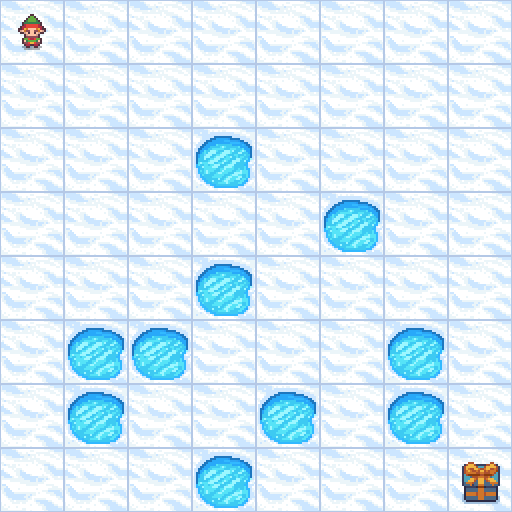

In [13]:
save_gif(success_frames, "dp_frozenlake_optimal_policy", fps=6, downscale=1)

## 10. Strengths, Weaknesses & Connections

### Strengths

- **Exact and provably convergent.** With a known model, DP finds $V^*$ and $\pi^*$ to any precision, with geometric
  convergence guaranteed by the contraction property.
- **No exploration problem.** Since we sweep over *all* states, there is no need to balance exploration and
  exploitation — one of the hardest problems in sample-based RL simply doesn't exist here.
- **Conceptual foundation.** Every quantity in later notebooks ($V$, $Q$, advantage, TD error, bootstrapping,
  greedy improvement) is introduced here in its purest form.

### Weaknesses

- **Requires the model.** In most interesting problems $P(s'|s,a)$ is unknown (robotics, games with hidden
  information, dialogue) or only available as a black-box simulator.
- **Curse of dimensionality.** Each sweep costs $O(|\mathcal{S}|^2 |\mathcal{A}|)$. Go has $\sim 10^{170}$ states;
  continuous control has infinitely many. Tabular DP is hopeless beyond a few million states.
- **Full sweeps are wasteful.** Many states are irrelevant to the optimal trajectory. *Asynchronous DP*, *prioritized
  sweeping*, and *real-time DP* address this by focusing updates where they matter.

### Connections

- **Q-learning** (next notebook) is value iteration with the expectation over $P$ replaced by a single sampled transition
  — *sample-based, model-free* DP.
- **DQN** is the same idea with $Q$ represented by a neural network instead of a table.
- **Policy iteration** is the template for **actor-critic** methods: the critic performs (partial) policy evaluation, the
  actor performs (soft) policy improvement. This is the generalized policy iteration (GPI) view of Sutton & Barto.
- **Model-based RL** — Dyna (Sutton, 1990), **AlphaZero** (planning with MCTS in a known simulator), **MuZero**
  (planning in a *learned* model) — brings the DP philosophy back at scale: if you have (or can learn) a model, plan with it.
- **LQR / Riccati equations** in control theory are DP for linear systems with quadratic costs, and give closed-form
  value functions.

## 11. References

1. **Bellman, R.** (1957). *Dynamic Programming.* Princeton University Press.
2. **Howard, R. A.** (1960). *Dynamic Programming and Markov Processes.* MIT Press.
3. **Puterman, M. L.** (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming.* Wiley.
4. **Sutton, R. S., & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.), Chapter 4. MIT Press.
   [[free online]](http://incompleteideas.net/book/the-book-2nd.html)
5. **Bertsekas, D. P.** (2012). *Dynamic Programming and Optimal Control*, Vol. I & II. Athena Scientific.
6. **Sutton, R. S.** (1990). *Integrated architectures for learning, planning, and reacting based on approximating dynamic programming.* ICML (Dyna).
7. **Schrittwieser, J., et al.** (2020). *Mastering Atari, Go, chess and shogi by planning with a learned model.* Nature (MuZero).